# 01. EDA - RFP 데이터 탐색적 분석

RFP 문서와 메타데이터를 탐색하여 데이터의 전반적인 특성을 파악합니다.

- 메타데이터 구조 및 분포 분석
- 문서 포맷별 분포 (hwp, pdf, docx)
- 결측치 확인
- 텍스트 길이 분포
- 발주 기관, 사업 금액 등 주요 변수 분석

> **Input**: `data/raw/metadata/data_list.csv` + `data/raw/rfp/` (101개 문서)  
> **Output**: 분석 결과만 (파일 출력 없음)  
> **Prev**: - | **Next**: [02_preprocessing.ipynb](02_preprocessing.ipynb)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import os
from pathlib import Path

## 1. 데이터 경로 설정

In [2]:
BASE_DIR = Path("../../data/raw")
METADATA_PATH = BASE_DIR / "metadata" / "data_list.csv"
RFP_DIR = BASE_DIR / "rfp"

print(f"메타데이터 경로: {METADATA_PATH}")
print(f"RFP 문서 경로: {RFP_DIR}")
print(f"메타데이터 존재: {METADATA_PATH.exists()}")
print(f"RFP 폴더 존재: {RFP_DIR.exists()}")

메타데이터 경로: ../../data/raw/metadata/data_list.csv
RFP 문서 경로: ../../data/raw/rfp
메타데이터 존재: True
RFP 폴더 존재: True


## 2. 메타데이터 로딩 및 기본 정보 확인

In [3]:
df = pd.read_csv(METADATA_PATH, encoding='utf-8-sig')
print(f"전체 행 수: {len(df)}")
print(f"컬럼: {list(df.columns)}")
df.head()

전체 행 수: 100
컬럼: ['공고 번호', '공고 차수', '사업명', '사업 금액', '발주 기관', '공개 일자', '입찰 참여 시작일', '입찰 참여 마감일', '사업 요약', '파일형식', '파일명', '텍스트']


,공고 번호,공고 차수,사업명,사업 금액,발주 기관,공개 일자,입찰 참여 시작일,입찰 참여 마감일,사업 요약,파일형식,파일명,텍스트
0,20241001798,0.0,한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보시스템 고도화,130000000.0,한영대학,2024-10-04 13:51:23,NaN,2024-10-15 17:00:00,- 한영대학교 특성화 맞춤형 교육환경 구축을 위해 트랙운영 학사정보시스템을 고도화한...,hwp,한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보.hwp,\n \n2024년 특성화 맞춤형 교육환경 구축 – 트랙운영 학사정보시스템 ...
1,20241002912,0.0,2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선,129300000.0,한국연구재단,2024-10-04 15:01:52,2024-10-14 10:00:00,2024-10-16 14:00:00,- 사업 개요: 2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선\n...,hwp,한국연구재단_2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선.hwp,\r\n \r\n \r\n \r\n제 안 요 청 서\r\n[ 2024년 대학 ...
2,20240827859,0.0,EIP3.0 고압가스 안전관리 시스템 구축 용역,40000000.0,한국생산기술연구원,2024-08-28 11:31:02,2024-08-29 09:00:00,2024-09-09 10:00:00,- 사업 개요: EIP3.0 고압가스 안전관리 시스템 구축 용역\n- 추진배경: 안...,hwp,한국생산기술연구원_EIP3.0 고압가스 안전관리 시스템 구축 용역.hwp,\r\n \r\nEIP3.0 고압가스 안전관리\r\n시스템 구축 용역\...
3,20240430918,0.0,도시계획위원회 통합관리시스템 구축용역,150000000.0,인천광역시,2024-04-18 16:26:32,2024-05-02 10:00:00,2024-05-09 16:00:00,- 사업명: 도시계획위원회 통합관리시스템 구축 용역\n- 용역개요: 도시계획위원회와...,hwp,인천광역시_도시계획위원회 통합관리시스템 구축용역.hwp,\r\n \r\n \r\n도시계획위원회 통합관리시스템 구축\r\n제 안 요 청...
4,20240430896,0.0,봉화군 재난통합관리시스템 고도화 사업(협상)(긴급),900000000.0,경상북도 봉화군,2024-04-18 16:33:28,2024-04-26 09:00:00,2024-04-30 17:00:00,- 사업명: 봉화군 재난통합관리시스템 고도화 사업\n- 사업개요: 공동수급(공동이행...,hwp,경상북도 봉화군_봉화군 재난통합관리시스템 고도화 사업(협상)(긴급).hwp,\r\n \r\n \r\n제안요청서\r\n \r\n사 업 명\r\n봉화...


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   공고 번호      82 non-null     str    
 1   공고 차수      82 non-null     float64
 2   사업명        100 non-null    str    
 3   사업 금액      99 non-null     float64
 4   발주 기관      100 non-null    str    
 5   공개 일자      100 non-null    str    
 6   입찰 참여 시작일  74 non-null     str    
 7   입찰 참여 마감일  92 non-null     str    
 8   사업 요약      100 non-null    str    
 9   파일형식       100 non-null    str    
 10  파일명        100 non-null    str    
 11  텍스트        100 non-null    str    
dtypes: float64(2), str(10)
memory usage: 853.9 KB


In [5]:
df.describe(include='all')

,공고 번호,공고 차수,사업명,사업 금액,발주 기관,공개 일자,입찰 참여 시작일,입찰 참여 마감일,사업 요약,파일형식,파일명,텍스트
count,82,82.000000,100,9.900000e+01,100,100,74,92,100,100,100,100
unique,82,NaN,99,NaN,87,99,73,87,100,2,100,100
top,20241001798,NaN,통합정보시스템 고도화 용역,NaN,한국수자원공사,2024-05-31 00:00:00,2024-06-28 10:00:00,2024-07-02 10:00:00,- 한영대학교 특성화 맞춤형 교육환경 구축을 위해 트랙운영 학사정보시스템을 고도화한...,hwp,한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보.hwp,\n \n2024년 특성화 맞춤형 교육환경 구축 – 트랙운영 학사정보시스템 ...
freq,1,NaN,2,NaN,3,2,2,3,1,96,1,1
mean,NaN,0.097561,NaN,6.906720e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,0.372173,NaN,1.966691e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,0.000000,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,0.000000,NaN,7.000000e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,0.000000,NaN,1.727000e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,0.000000,NaN,4.064889e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. 결측치 분석

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'결측 수': missing, '결측 비율(%)': missing_pct})
missing_df[missing_df['결측 수'] > 0].sort_values('결측 비율(%)', ascending=False)

,결측 수,결측 비율(%)
입찰 참여 시작일,26,26.0
공고 번호,18,18.0
공고 차수,18,18.0
입찰 참여 마감일,8,8.0
사업 금액,1,1.0


## 4. 파일 포맷 분포

In [7]:
print("메타데이터 기준 파일형식 분포:")
display(df['파일형식'].value_counts().to_frame('문서 수'))

rfp_files = list(RFP_DIR.iterdir())
extensions = pd.Series([f.suffix.lower() for f in rfp_files])
print(f"\n실제 RFP 폴더 파일 확장자 분포 (총 {len(rfp_files)}개):")
display(extensions.value_counts().to_frame('파일 수'))


메타데이터 기준 파일형식 분포:


,문서 수
파일형식,
hwp,96
pdf,4



실제 RFP 폴더 파일 확장자 분포 (총 101개):


,파일 수
.hwp,96
.pdf,4
.docx,1


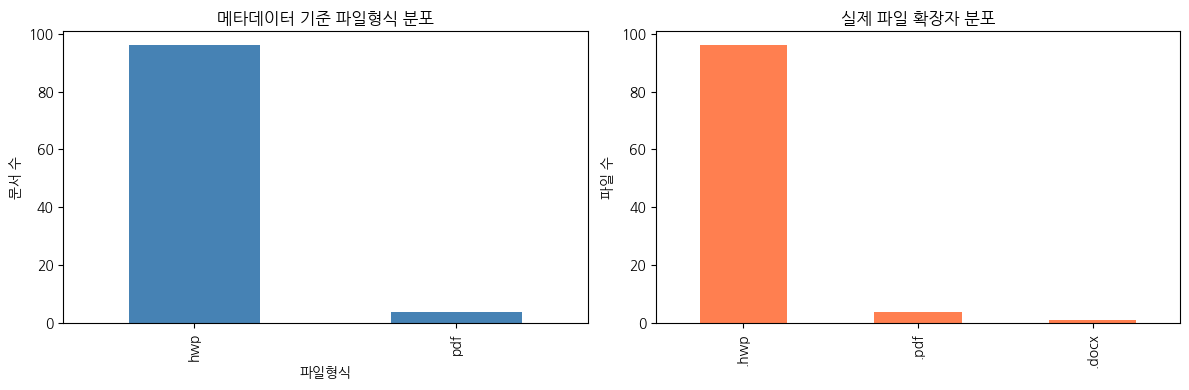

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['파일형식'].value_counts().plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('메타데이터 기준 파일형식 분포')
axes[0].set_ylabel('문서 수')

extensions.value_counts().plot.bar(ax=axes[1], color='coral')
axes[1].set_title('실제 파일 확장자 분포')
axes[1].set_ylabel('파일 수')

plt.tight_layout()
plt.show()

## 5. 발주 기관 분석

In [9]:
print(f"고유 발주 기관 수: {df['발주 기관'].nunique()}")

top15 = df['발주 기관'].value_counts().head(15).to_frame('건수')
top15.index.name = '발주 기관'
display(top15)


고유 발주 기관 수: 87


,건수
발주 기관,
한국수자원공사,3
한국철도공사 (용역),3
한국연구재단,2
한국생산기술연구원,2
인천광역시,2
국방과학연구소,2
수협중앙회,2
한국농어촌공사,2
축산물품질평가원,2


## 6. 사업 금액 분석

In [10]:
budget = df['사업 금액'].dropna()

budget_stats = pd.DataFrame({
    '지표': ['건수', '평균', '중앙값', '최소', '최대', '표준편차'],
    '값': [
        f"{len(budget)}건",
        f"{budget.mean():,.0f}원 ({budget.mean()/1e8:.2f}억)",
        f"{budget.median():,.0f}원 ({budget.median()/1e8:.2f}억)",
        f"{budget.min():,.0f}원",
        f"{budget.max():,.0f}원 ({budget.max()/1e8:.1f}억)",
        f"{budget.std():,.0f}원",
    ]
}).set_index('지표')
display(budget_stats)

bins = [0, 5e7, 1e8, 3e8, 5e8, 1e9, 5e9, float('inf')]
labels = ['~5천만', '5천만~1억', '1~3억', '3~5억', '5~10억', '10~50억', '50억~']
budget_cat = pd.cut(budget, bins=bins, labels=labels)
print("\n금액대별 분포:")
display(budget_cat.value_counts().sort_index().to_frame('건수'))

zero_budget = df[df['사업 금액'] == 0]
if len(zero_budget):
    print(f"\n사업 금액 = 0원 ({len(zero_budget)}건):")
    display(zero_budget[['사업명']].reset_index(drop=True))


,값
지표,
건수,99건
평균,"690,671,980원 (6.91억)"
중앙값,"172,700,000원 (1.73억)"
최소,0원
최대,"14,107,009,000원 (141.1억)"
표준편차,"1,966,690,586원"



금액대별 분포:


,건수
사업 금액,
~5천만,13
5천만~1억,18
1~3억,30
3~5억,11
5~10억,11
10~50억,6
50억~,4



사업 금액 = 0원 (6건):


,사업명
0,[사전공개] 학업성취도 다차원 종단분석 통합시스템 1차 고도화 용역
1,[입찰공고] 산학협력단 정보시스템 운영 용역업체 선정
2,예약발매시스템 개량 ISMP 용역
3,모바일오피스 시스템 고도화 용역(총체 및 1차)
4,을지대학교 비교과시스템 개발
5,[재공고][긴급][협상형]운행정보기록 자동분석시스템 개량


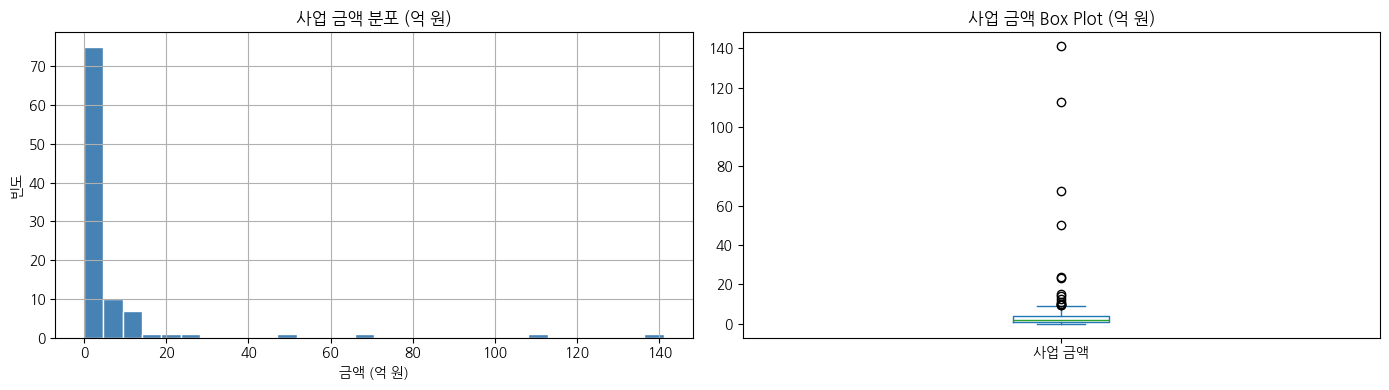

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

budget_억 = budget / 1e8
budget_억.hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('사업 금액 분포 (억 원)')
axes[0].set_xlabel('금액 (억 원)')
axes[0].set_ylabel('빈도')

budget_억.plot.box(ax=axes[1])
axes[1].set_title('사업 금액 Box Plot (억 원)')

plt.tight_layout()
plt.show()

## 7. 텍스트 길이 분석

In [12]:
df['텍스트_길이'] = df['텍스트'].fillna('').str.len()

text_stats = pd.DataFrame({
    '지표': ['평균', '중앙값', '최소', '최대', '표준편차', '텍스트 없음(0자)', '1000자 미만'],
    '값': [
        f"{df['텍스트_길이'].mean():,.0f}자",
        f"{df['텍스트_길이'].median():,.0f}자",
        f"{df['텍스트_길이'].min():,.0f}자",
        f"{df['텍스트_길이'].max():,.0f}자",
        f"{df['텍스트_길이'].std():,.0f}자",
        f"{(df['텍스트_길이'] == 0).sum()}건",
        f"{(df['텍스트_길이'] < 1000).sum()}건",
    ]
}).set_index('지표')
display(text_stats)

print("\n분위수:")
quantiles = pd.DataFrame({
    '분위': [f'{q*100:.0f}%ile' for q in [0.1, 0.25, 0.5, 0.75, 0.9, 0.95]],
    '글자 수': [f"{df['텍스트_길이'].quantile(q):,.0f}자" for q in [0.1, 0.25, 0.5, 0.75, 0.9, 0.95]],
}).set_index('분위')
display(quantiles)


,값
지표,
평균,"3,844자"
중앙값,"2,583자"
최소,89자
최대,"18,335자"
표준편차,"3,693자"
텍스트 없음(0자),0건
1000자 미만,21건



분위수:


,글자 수
분위,
10%ile,604자
25%ile,"1,198자"
50%ile,"2,583자"
75%ile,"5,842자"
90%ile,"7,675자"
95%ile,"8,783자"


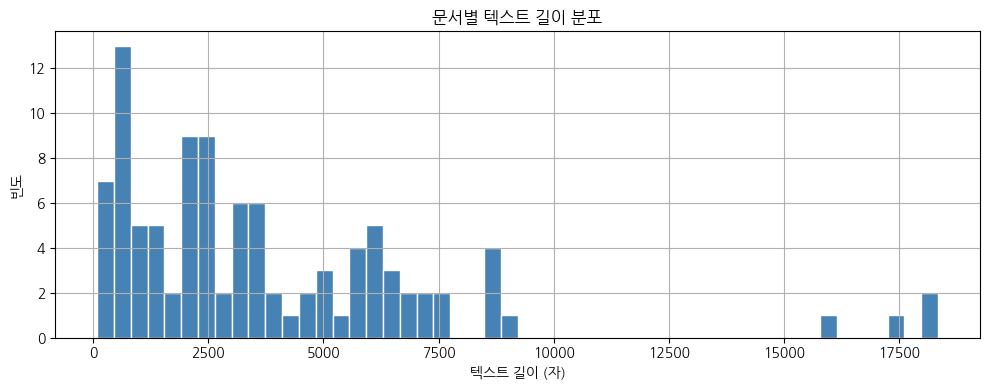

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
df['텍스트_길이'].hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('문서별 텍스트 길이 분포')
ax.set_xlabel('텍스트 길이 (자)')
ax.set_ylabel('빈도')
plt.tight_layout()
plt.show()

## 8. 사업 요약 길이 분석

In [14]:
df['요약_길이'] = df['사업 요약'].fillna('').str.len()

summary_stats = pd.DataFrame({
    '지표': ['평균', '중앙값', '요약 없음(0자)'],
    '값': [f"{df['요약_길이'].mean():,.0f}자", f"{df['요약_길이'].median():,.0f}자", f"{(df['요약_길이']==0).sum()}건"]
}).set_index('지표')
display(summary_stats)


,값
지표,
평균,269자
중앙값,250자
요약 없음(0자),0건


## 9. 일자 분석

공개 일자 범위: 2021-10-08 00:00:00 ~ 2025-02-11 13:32:46


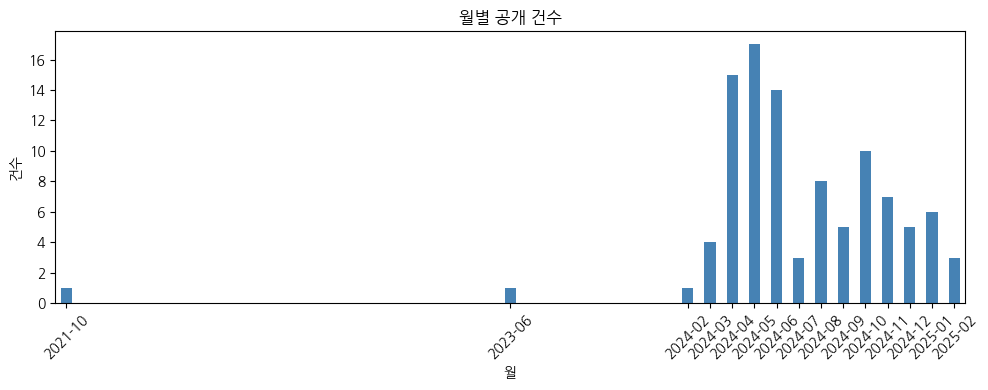

In [15]:
df['공개_일자_dt'] = pd.to_datetime(df['공개 일자'], errors='coerce')

print(f"공개 일자 범위: {df['공개_일자_dt'].min()} ~ {df['공개_일자_dt'].max()}")

fig, ax = plt.subplots(figsize=(10, 4))
df['공개_일자_dt'].dt.to_period('M').value_counts().sort_index().plot.bar(ax=ax, color='steelblue')
ax.set_title('월별 공개 건수')
ax.set_xlabel('월')
ax.set_ylabel('건수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. 메타데이터와 실제 파일 매칭 확인

In [16]:
# 메타데이터의 파일명과 실제 RFP 폴더 파일 비교
meta_files = set(df['파일명'].dropna().tolist())
actual_files = set(f.name for f in RFP_DIR.iterdir())

only_in_meta = meta_files - actual_files
only_in_folder = actual_files - meta_files
matched = meta_files & actual_files

print(f"메타데이터 파일 수: {len(meta_files)}")
print(f"실제 폴더 파일 수: {len(actual_files)}")
print(f"매칭된 파일 수: {len(matched)}")
print(f"\n메타데이터에만 있는 파일 ({len(only_in_meta)}건):")
for f in sorted(only_in_meta):
    print(f"  - {f}")

print(f"\n폴더에만 있는 파일 ({len(only_in_folder)}건):")
for f in sorted(only_in_folder):
    print(f"  - {f}")

메타데이터 파일 수: 100
실제 폴더 파일 수: 101
매칭된 파일 수: 100

메타데이터에만 있는 파일 (0건):

폴더에만 있는 파일 (1건):
  - 고려대학교_차세대 포털·학사 정보시스템 구축사업.docx


## 11. 파일 크기 분석

In [17]:
file_sizes = []
for f in RFP_DIR.iterdir():
    file_sizes.append({'파일명': f.name, '확장자': f.suffix.lower(), '크기_MB': f.stat().st_size / (1024 * 1024)})

size_df = pd.DataFrame(file_sizes)
display(size_df['크기_MB'].describe().round(2).to_frame('크기(MB)'))

print("\n확장자별 평균 크기:")
display(size_df.groupby('확장자')['크기_MB'].agg(['count', 'mean']).round(2).rename(columns={'count': '파일 수', 'mean': '평균(MB)'}))


,크기(MB)
count,101.00
mean,1.62
std,2.60
min,0.14
25%,0.51
50%,0.92
75%,1.54
max,22.99



확장자별 평균 크기:


,파일 수,평균(MB)
확장자,,
.docx,1,0.44
.hwp,96,1.56
.pdf,4,3.18


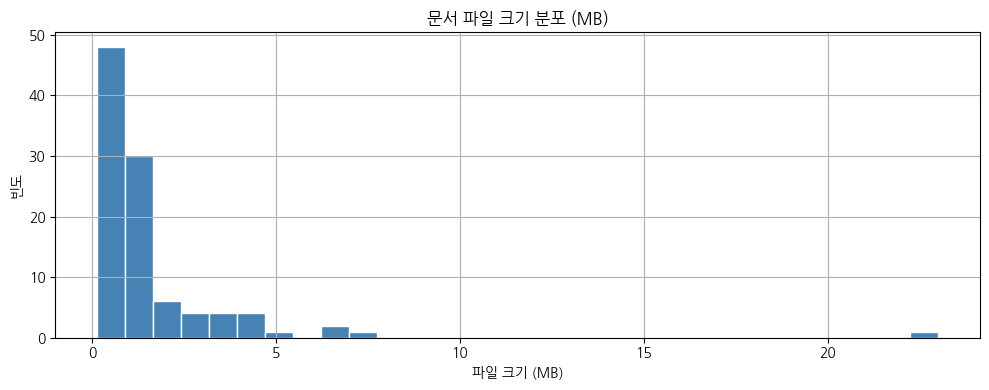

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
size_df['크기_MB'].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('문서 파일 크기 분포 (MB)')
ax.set_xlabel('파일 크기 (MB)')
ax.set_ylabel('빈도')
plt.tight_layout()
plt.show()

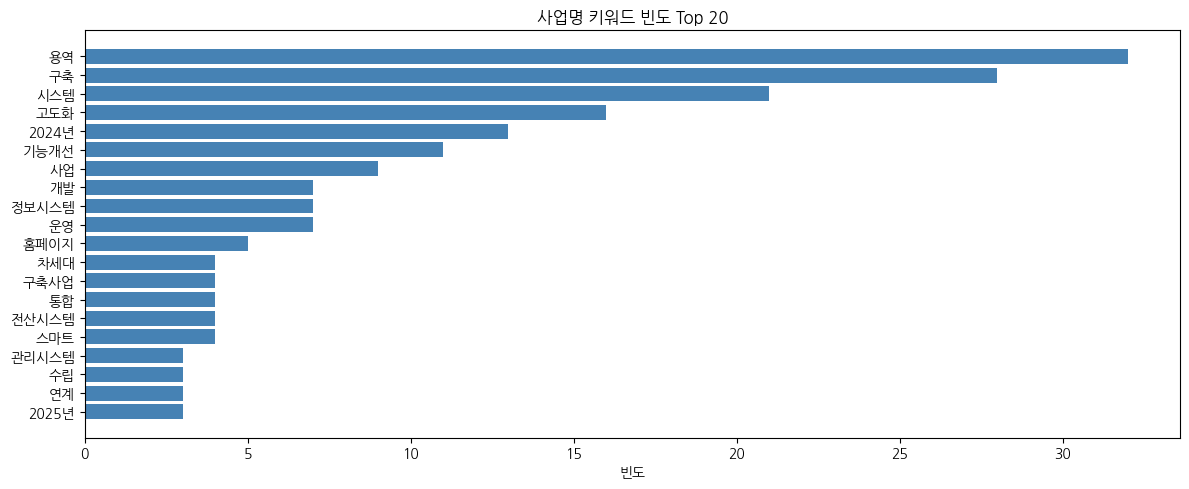

=== Top 20 키워드 ===
  용역: 32건
  구축: 28건
  시스템: 21건
  고도화: 16건
  2024년: 13건
  기능개선: 11건
  사업: 9건
  개발: 7건
  정보시스템: 7건
  운영: 7건
  홈페이지: 5건
  차세대: 4건
  구축사업: 4건
  통합: 4건
  전산시스템: 4건
  스마트: 4건
  관리시스템: 3건
  수립: 3건
  연계: 3건
  2025년: 3건


In [19]:
keywords = {}
for name in df['사업명']:
    for word in str(name).split():
        if len(word) >= 2:
            keywords[word] = keywords.get(word, 0) + 1

top_kw = sorted(keywords.items(), key=lambda x: -x[1])[:20]
kw_df = pd.DataFrame(top_kw, columns=['키워드', '빈도'])

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(kw_df['키워드'][::-1], kw_df['빈도'][::-1], color='steelblue')
ax.set_title('사업명 키워드 빈도 Top 20')
ax.set_xlabel('빈도')
plt.tight_layout()
plt.show()

print("=== Top 20 키워드 ===")
for w, c in top_kw:
    print(f"  {w}: {c}건")

## 13. 텍스트 품질 분석 - 파일크기 대비 텍스트 추출률

CSV의 텍스트 컬럼이 원본 파일 대비 얼마나 추출되었는지 확인합니다.
추출률이 극단적으로 낮은 문서는 텍스트 손실 가능성이 높습니다.

In [20]:
size_map = {f.name: f.stat().st_size for f in RFP_DIR.iterdir()}
df['파일_크기_bytes'] = df['파일명'].map(size_map)
df['추출률(%)'] = df['텍스트_길이'] / df['파일_크기_bytes'].fillna(1) * 100

print("파일크기 대비 텍스트 추출률이 가장 낮은 문서 Top 10:")
print("(텍스트 손실 가능성 높음 -> 전처리 시 원본에서 재추출 필요)")
low_extract = df.nsmallest(10, '추출률(%)')[['사업명', '파일형식', '텍스트_길이', '파일_크기_bytes', '추출률(%)']].copy()
low_extract['파일크기(KB)'] = (low_extract['파일_크기_bytes'] / 1024).round(0).astype(int)
low_extract['추출률(%)'] = low_extract['추출률(%)'].round(3)
low_extract = low_extract[['사업명', '파일형식', '텍스트_길이', '파일크기(KB)', '추출률(%)']].reset_index(drop=True)
low_extract.index = low_extract.index + 1
low_extract.index.name = '순위'
display(low_extract)


파일크기 대비 텍스트 추출률이 가장 낮은 문서 Top 10:
(텍스트 손실 가능성 높음 -> 전처리 시 원본에서 재추출 필요)


,사업명,파일형식,텍스트_길이,파일크기(KB),추출률(%)
순위,,,,,
1,2024년 건설기술에 관한 특허·실용신안 활용실적 관리시스템 개편 용역,hwp,89,928,0.009
2,[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 국회 방송시스템 구축 ...,hwp,2351,23546,0.010
3,[사전공개] 학업성취도 다차원 종단분석 통합시스템 1차 고도화 용역,pdf,220,2199,0.010
4,2024년 벤처확인종합관리시스템 기능 고도화 용역사업 입찰공고,hwp,533,4163,0.013
5,JST 공유대학(원) xAPI기반 LRS시스템 구축,hwp,130,896,0.014
6,EIP3.0 고압가스 안전관리 시스템 구축 용역,hwp,234,1442,0.016
7,아태 사이버범죄 역량강화 허브(APC-HUB) 홈페이지 및 온라인 교육시스템 고도화...,hwp,806,3584,0.022
8,사업장 사회보험료 지원 고시 개정에 따른 정보시스템 보완 개발,hwp,401,1678,0.023
9,2024년 지도정보 플랫폼 및 전문활용 연계 시스템 고도화 용역,pdf,808,3120,0.025


## 14. 텍스트 품질 샘플 확인

가장 짧은 문서들의 실제 텍스트를 확인하여 품질 이슈를 파악합니다.

In [21]:
print("=== 텍스트가 가장 짧은 문서 Top 5 ===\n")
for _, row in df.nsmallest(5, '텍스트_길이').iterrows():
    print(f"--- {row['사업명']} ({row['텍스트_길이']}자, {row['파일형식']}) ---")
    print(repr(row['텍스트'][:300]))
    print()

print("\n=== 공백 비율이 높은 문서 Top 5 ===\n")
df['공백비율(%)'] = df['텍스트'].fillna('').apply(
    lambda x: sum(1 for c in x if c in ' \t\n\r') / max(len(x), 1) * 100
).round(1)
for _, row in df.nlargest(5, '공백비율(%)').iterrows():
    print(f"  {row['사업명'][:45]:45s} | {row['텍스트_길이']:>5}자 | 공백 {row['공백비율(%)']:.1f}%")

=== 텍스트가 가장 짧은 문서 Top 5 ===

--- 2024년 건설기술에 관한 특허·실용신안 활용실적 관리시스템 개편 용역 (89자, hwp) ---
'    \r\n \r\n2024년 건설기술에 관한 특허-실용신안 활용실적 관리시스템 개편 용역 제안요청서\r\n2024. 4.\r\n   \r\n \r\n기업성장지원실\r\n \r\n부서명'

--- JST 공유대학(원) xAPI기반 LRS시스템 구축 (130자, hwp) ---
'   \r\n   \r\n \r\n \r\n JST 공유대학(원) xAPI기반 LRS시스템 구축 \r\n 제 안 요 청 서\r\n2024. 9.\r\n \r\n   \r\n \r\n사 업 명\r\nJST 공유대학(원) xAPI 기반 LRS시스템 구축\r\n주관기관\r\n전북지역혁'

--- 2025 구미아시아육상경기선수권대회 종합정보시스템 및 홈페이지 등 구축 용역 (186자, hwp) ---
'     \r\n \r\n종합정보시스템 및 홈페이지 등 구축 용역 제안요청서\r\n \r\n1\r\n 대회개요\r\n \r\n \r\n아시아의 꿈, 구미에서 세계로\r\n  The dream of ASIA, From GUMI to the World  \r\n비전\r\n ㅇ (대 회 명) 2025 구미아시아육상경기선수권대회\r\n ㅇ (기    간) 2025. 5. 27.(화'

--- [사전공개] 학업성취도 다차원 종단분석 통합시스템 1차 고도화 용역 (220자, pdf) ---
'[사전공개용]\n제  안  요  청  서\n\n사  업  명\n\n학업성취도 다차원 종단분석 통합시스템 1차 고도화\n\n주관기관\n\n서 울 시 립 대 학 교   입 학 처 \n\n본   제 안 요 청 서 는   입 찰 참 여 의   균 등 한   기 회   제 공 을   위 해 \n규 격 을   공 개 하 기   위 한   자 료 로 써   실제  입찰공고  시  사업금액, \n과업내용,  평가항목,  제출서류'

--- EIP3.0 고압가스 안전관리 시

## 15. 중복 데이터 확인

In [22]:
print("=== 중복 사업명 ===")
dup_names = df['사업명'].value_counts()
dups = dup_names[dup_names > 1]
if len(dups):
    for name, cnt in dups.items():
        rows = df[df['사업명'] == name][['사업명', '발주 기관', '파일형식', '공개 일자']]
        print(f"\n  '{name}' ({cnt}건):")
        print(rows.to_string(index=False))
else:
    print("  없음")

print(f"\n=== 고유 공고번호 수: {df['공고 번호'].nunique()} (결측 {df['공고 번호'].isnull().sum()}건 제외) ===")
print(f"\n=== 공고 차수 분포 ===")
print(df['공고 차수'].value_counts(dropna=False).to_string())

=== 중복 사업명 ===

  '통합정보시스템 고도화 용역' (2건):
           사업명         발주 기관 파일형식               공개 일자
통합정보시스템 고도화 용역 국가과학기술지식정보서비스  hwp 2024-05-30 00:00:00
통합정보시스템 고도화 용역      한국한의학연구원  hwp 2024-05-30 09:04:12

=== 고유 공고번호 수: 82 (결측 18건 제외) ===

=== 공고 차수 분포 ===
공고 차수
0.0    76
NaN    18
1.0     4
2.0     2


## 17. 발주기관 유형 분류 분석

발주기관을 유형별로 분류하면 RAG 시스템의 사용 패턴을 예측할 수 있습니다.
예: 대학교는 학사시스템, 공공기관은 행정시스템, 연구기관은 연구인프라 관련 RFP가 많을 수 있음.

=== 발주기관 유형별 분포 ===
  공기업/공공기관       :  29건 (29%)
  지방자치단체         :  28건 (28%)
  협회/재단          :  15건 (15%)
  대학교            :  11건 (11%)
  기타             :  11건 (11%)
  연구기관           :   3건 (3%)
  민간기업           :   3건 (3%)


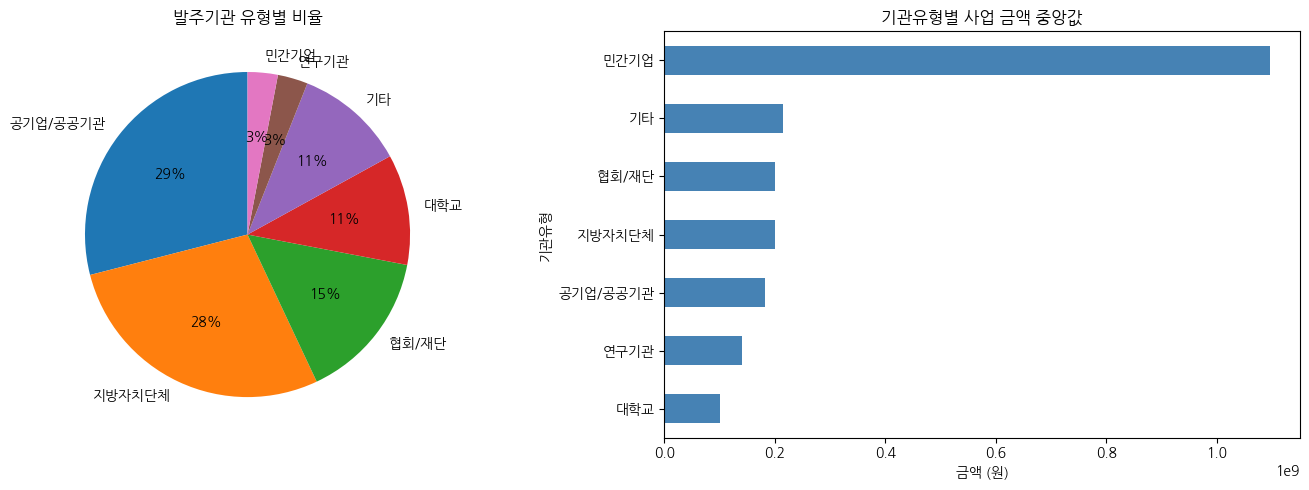

In [23]:
def classify_agency(name: str) -> str:
    """발주기관명을 유형별로 분류한다."""
    name = str(name)
    if any(k in name for k in ['대학', '학교']):
        return '대학교'
    elif any(k in name for k in ['공사', '공단', '공사 ', '진흥원', '진흥회', '평가원']):
        return '공기업/공공기관'
    elif any(k in name for k in ['시', '도', '군', '구', '청', '광역']):
        return '지방자치단체'
    elif any(k in name for k in ['연구원', '연구소', '과학']):
        return '연구기관'
    elif any(k in name for k in ['협회', '협의회', '재단', '센터', '원']):
        return '협회/재단'
    elif any(k in name for k in ['(주)', '주식회사', '㈜']):
        return '민간기업'
    else:
        return '기타'

df['기관유형'] = df['발주 기관'].apply(classify_agency)

print("=== 발주기관 유형별 분포 ===")
type_counts = df['기관유형'].value_counts()
for t, c in type_counts.items():
    print(f"  {t:15s}: {c:3d}건 ({c/len(df)*100:.0f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
type_counts.plot.pie(ax=axes[0], autopct='%1.0f%%', startangle=90)
axes[0].set_title('발주기관 유형별 비율')
axes[0].set_ylabel('')

df.groupby('기관유형')['사업 금액'].median().sort_values().plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('기관유형별 사업 금액 중앙값')
axes[1].set_xlabel('금액 (원)')
plt.tight_layout()
plt.show()


## 18. 사업 도메인 분류

사업명 키워드를 기반으로 도메인을 분류합니다.
도메인별 문서 특성을 파악하면 질문 세트 설계와 평가 기준 수립에 활용할 수 있습니다.

=== 사업 도메인별 분포 ===
  기타 정보시스템       :  51건
  교육/학습          :  12건
  안전/보안          :   7건
  경영/행정          :   7건
  웹/포털           :   6건
  AI/데이터         :   5건
  의료/바이오         :   5건
  ISP/컨설팅        :   5건
  공간정보/GIS       :   2건


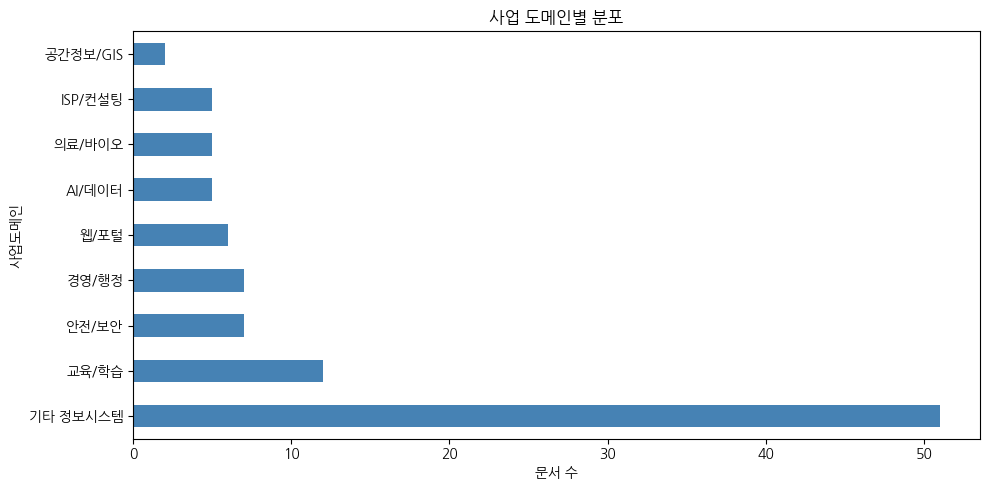

In [24]:
def classify_domain(name: str) -> str:
    """사업명을 도메인별로 분류한다."""
    name = str(name)
    if any(k in name for k in ['교육', '이러닝', '학습', '학사', 'LMS', 'LRS', '연수']):
        return '교육/학습'
    elif any(k in name for k in ['안전', '재난', '방재', '관제', '보안']):
        return '안전/보안'
    elif any(k in name for k in ['홈페이지', '포털', '웹', 'UI', 'UX']):
        return '웹/포털'
    elif any(k in name for k in ['ERP', '그룹웨어', '경영', '인사', '회계', '전자결재']):
        return '경영/행정'
    elif any(k in name for k in ['GIS', '지도', '공간', '측량', '수문']):
        return '공간정보/GIS'
    elif any(k in name for k in ['의료', '건강', '바이오', '선량']):
        return '의료/바이오'
    elif any(k in name for k in ['ISP', '전략', '컨설팅', '타당성']):
        return 'ISP/컨설팅'
    elif any(k in name for k in ['데이터', 'AI', '빅데이터', '분석']):
        return 'AI/데이터'
    else:
        return '기타 정보시스템'

df['사업도메인'] = df['사업명'].apply(classify_domain)

print("=== 사업 도메인별 분포 ===")
domain_counts = df['사업도메인'].value_counts()
for d, c in domain_counts.items():
    print(f"  {d:15s}: {c:3d}건")

fig, ax = plt.subplots(figsize=(10, 5))
domain_counts.plot.barh(ax=ax, color='steelblue')
ax.set_title('사업 도메인별 분포')
ax.set_xlabel('문서 수')
plt.tight_layout()
plt.show()


## 19. 변수 간 관계 분석

사업 금액, 텍스트 길이, 파일 크기 간의 관계를 확인합니다.
이 관계가 RAG 파이프라인 설계에 주는 시사점을 도출합니다.

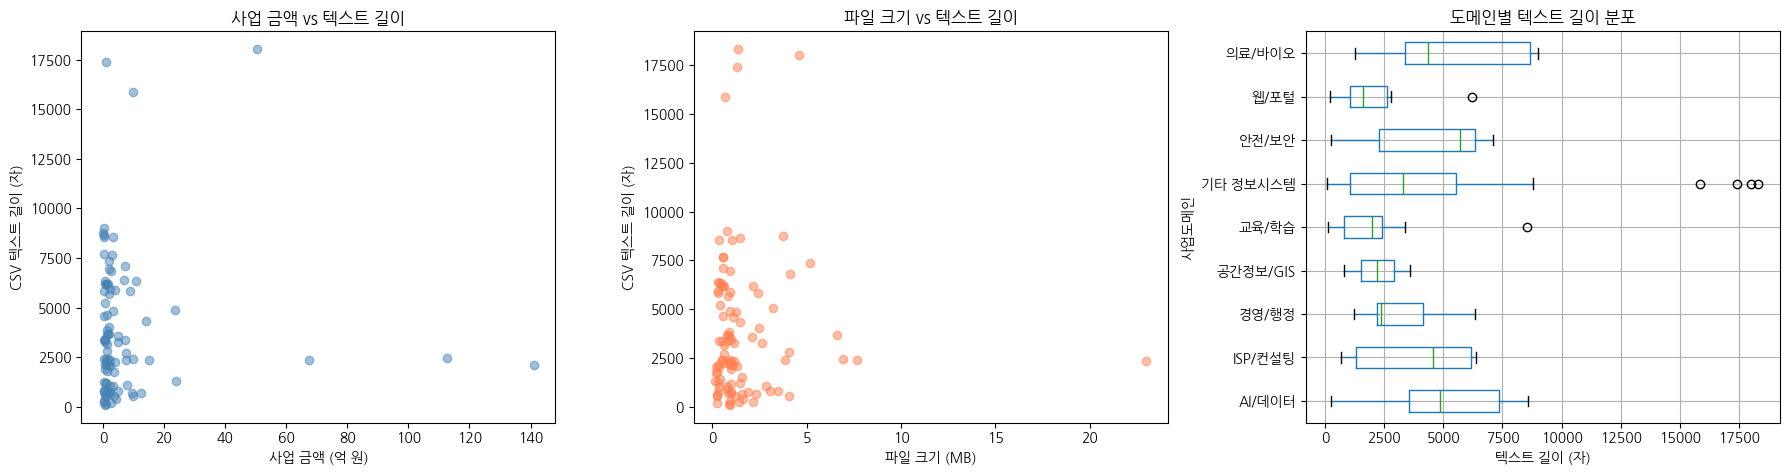

수치 변수 상관계수:


,사업 금액,텍스트_길이,요약_길이,파일크기_MB
사업 금액,1.00,0.02,0.05,0.38
텍스트_길이,0.02,1.00,-0.02,0.00
요약_길이,0.05,-0.02,1.00,-0.02
파일크기_MB,0.38,0.00,-0.02,1.00


In [25]:
from pathlib import Path
RFP_DIR = Path("../../data/raw/rfp")
size_map = {f.name: f.stat().st_size / (1024*1024) for f in RFP_DIR.iterdir()}
df['파일크기_MB'] = df['파일명'].map(size_map)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

valid = df[(df['사업 금액'] > 0) & (df['텍스트_길이'] > 0)]
axes[0].scatter(valid['사업 금액'] / 1e8, valid['텍스트_길이'], alpha=0.5, c='steelblue')
axes[0].set_xlabel('사업 금액 (억 원)')
axes[0].set_ylabel('CSV 텍스트 길이 (자)')
axes[0].set_title('사업 금액 vs 텍스트 길이')

axes[1].scatter(df['파일크기_MB'], df['텍스트_길이'], alpha=0.5, c='coral')
axes[1].set_xlabel('파일 크기 (MB)')
axes[1].set_ylabel('CSV 텍스트 길이 (자)')
axes[1].set_title('파일 크기 vs 텍스트 길이')

df.boxplot(column='텍스트_길이', by='사업도메인', ax=axes[2], vert=False)
axes[2].set_title('도메인별 텍스트 길이 분포')
axes[2].set_xlabel('텍스트 길이 (자)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("수치 변수 상관계수:")
corr_cols = ['사업 금액', '텍스트_길이', '요약_길이', '파일크기_MB']
display(df[corr_cols].corr().round(2))


## 20. 결측치 처리 전략

결측치를 단순히 세는 것이 아니라, RAG 파이프라인에서 어떻게 처리할지 결정합니다.

In [26]:
print("=== 결측치 현황 및 처리 전략 ===")
print()
strategies = {
    '공고 번호': ('18건 (18%)', '메타데이터 필터링에 사용 -> 결측 시 파일명 기반 식별로 대체'),
    '공고 차수': ('18건 (18%)', '공고 번호와 동일 패턴 -> 0차로 간주 (첫 공고)'),
    '입찰 참여 시작일': ('26건 (26%)', '검색 필터로 사용하지 않으므로 결측 허용'),
    '입찰 참여 마감일': ('8건 (8%)', '동일'),
    '사업 금액': ('1건 결측 + 6건 0원', '0원은 사전공개/재공고 -> 메타데이터 필터링 시 제외 조건 설정'),
}

for col, (status, strategy) in strategies.items():
    print(f"  [{col}]")
    print(f"    현황: {status}")
    print(f"    전략: {strategy}")
    print()

print("=== RAG 파이프라인에서 핵심 메타데이터 ===")
print("  필수 (결측 0건): 사업명, 발주 기관, 파일명, 텍스트, 사업 요약")
print("  선택 (검색 필터용): 공고 번호, 사업 금액, 공개 일자")


=== 결측치 현황 및 처리 전략 ===

  [공고 번호]
    현황: 18건 (18%)
    전략: 메타데이터 필터링에 사용 -> 결측 시 파일명 기반 식별로 대체

  [공고 차수]
    현황: 18건 (18%)
    전략: 공고 번호와 동일 패턴 -> 0차로 간주 (첫 공고)

  [입찰 참여 시작일]
    현황: 26건 (26%)
    전략: 검색 필터로 사용하지 않으므로 결측 허용

  [입찰 참여 마감일]
    현황: 8건 (8%)
    전략: 동일

  [사업 금액]
    현황: 1건 결측 + 6건 0원
    전략: 0원은 사전공개/재공고 -> 메타데이터 필터링 시 제외 조건 설정

=== RAG 파이프라인에서 핵심 메타데이터 ===
  필수 (결측 0건): 사업명, 발주 기관, 파일명, 텍스트, 사업 요약
  선택 (검색 필터용): 공고 번호, 사업 금액, 공개 일자


## 21. EDA에서 도출한 RAG 파이프라인 시사점

지금까지의 분석 결과가 이후 단계에 어떤 영향을 주는지 정리합니다.

In [27]:
insights = [
    {'발견': 'CSV 텍스트는 원본의 3~5% 수준 (21건이 1,000자 미만)',
     '시사점': '원본 HWP/PDF에서 직접 재추출 필수',
     '적용 단계': '02_preprocessing'},
    {'발견': 'HWP 96%, PDF 4% - 대부분 HWP',
     '시사점': 'HWP 파서 품질이 전체 RAG 성능을 좌우',
     '적용 단계': '02_preprocessing'},
    {'발견': '발주기관 87개로 분산, 대부분 1~2건',
     '시사점': '메타데이터 필터링 시 유사 기관명 매칭 필요',
     '적용 단계': '06_retrieval'},
    {'발견': '사업 금액 중앙값 1.73억, 0원 6건',
     '시사점': '0원(사전공개) 처리 필요, 범위 검색 지원',
     '적용 단계': '06_retrieval'},
    {'발견': '사업 도메인이 다양 (교육, 안전, 웹, 경영 등)',
     '시사점': '도메인별 질문 세트 + 성능 비교 필요',
     '적용 단계': '08_evaluation'},
    {'발견': '사업 금액과 텍스트 길이 간 상관 낮음',
     '시사점': '청크 수로 문서 중요도 판단 불가',
     '적용 단계': '04_chunking'},
    {'발견': '고려대 문서가 PDF+DOCX 중복',
     '시사점': '중복 문서 처리 규칙 필요',
     '적용 단계': '02_preprocessing'},
]

insight_df = pd.DataFrame(insights)
display(insight_df)


,발견,시사점,적용 단계
0,"CSV 텍스트는 원본의 3~5% 수준 (21건이 1,000자 미만)",원본 HWP/PDF에서 직접 재추출 필수,02_preprocessing
1,"HWP 96%, PDF 4% - 대부분 HWP",HWP 파서 품질이 전체 RAG 성능을 좌우,02_preprocessing
2,"발주기관 87개로 분산, 대부분 1~2건",메타데이터 필터링 시 유사 기관명 매칭 필요,06_retrieval
3,"사업 금액 중앙값 1.73억, 0원 6건","0원(사전공개) 처리 필요, 범위 검색 지원",06_retrieval
4,"사업 도메인이 다양 (교육, 안전, 웹, 경영 등)",도메인별 질문 세트 + 성능 비교 필요,08_evaluation
5,사업 금액과 텍스트 길이 간 상관 낮음,청크 수로 문서 중요도 판단 불가,04_chunking
6,고려대 문서가 PDF+DOCX 중복,중복 문서 처리 규칙 필요,02_preprocessing


## 22. 종합 요약

### 데이터 개요
- **100건** RFP 메타데이터 (12개 컬럼), 실제 파일 101개
- HWP 96건, PDF 4건, DOCX 1건 (메타 미등록)

### 핵심 발견사항
1. **텍스트 품질 이슈**: CSV 텍스트는 원본 대비 3~5% 수준 -> 원본 재추출 필수
2. **파일 포맷**: HWP 96%로 압도적 -> HWP 파서(kordoc) 품질이 전체 성능 좌우
3. **발주기관**: 87개 기관, 대학교/공기업/지자체/연구기관 등 다양
4. **사업 도메인**: 교육, 안전, 웹/포털, 경영/행정 등 -> 도메인별 평가 필요
5. **금액 분포**: 중앙값 1.73억, 1~3억이 최다, 0원(사전공개) 6건 주의
6. **결측치**: 사업명/발주기관/텍스트는 결측 없음, 공고번호/참여일자 일부 결측

### 파이프라인 설계에 반영한 사항
| EDA 발견 | 반영 내용 | 적용 단계 |
|---|---|---|
| CSV 텍스트 부족 | kordoc으로 원본 재추출 | 전처리 |
| HWP 96% | kordoc(HWP 특화) 메인 파서 선정 | 전처리 |
| 발주기관 분산 | 메타데이터 필터링 + 유사명 매칭 | Retrieval |
| 도메인 다양 | 도메인별 질문 세트 + 성능 비교 | 평가 |
| 0원 사업 존재 | 금액 필터 시 예외 처리 | Retrieval |

### 다음 단계
- `02_preprocessing.ipynb`: kordoc + pdfplumber로 원본 텍스트 추출
- `03_cleaning.ipynb`: 노이즈 정제
- `04_chunking.ipynb`: 2단계 하이브리드 청킹
